# HH2 - Step 3: Temperature Model (Random Forests)

## Algorithm curent plan:
- Predict indoor temperatures from outdoor temperatures (forecasts), sunlight (forecasts), and window states (loop over all possibilities?)
> Random Forest ML model

- Predict 'presets' for the sensors:
> Designerly Baseline Model

### Import libraries 

In [4]:
#Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn' ## disable chained assignment warnings due to false positives
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
#Plotly is a Python data visualization library 
import plotly.graph_objects as go
import plotly.express as px
import datetime as dt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Import metrics
from sklearn.ensemble import RandomForestRegressor

### Load and view data 

In [6]:
# Get the merged database (saved at the end of notebook STEP 1)
database = pd.read_csv (r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_merged.csv")
database.drop(['weather_main', "Temperature_outdoor", 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)

database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_hourly.csv")
database_hourly['ts'] = pd.to_datetime(database_hourly['ts'])  # Specify the correct format
database_hourly.drop(['weather_main', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)


# Get a database with one row per 30 minutes
# Convert 'ts' to datetime
database['ts'] = pd.to_datetime(database['ts'])
# Resample to 30-minute intervals, using mean or another aggregation function
database_30min = database.resample('30T', on='ts').agg(lambda x: x.mode()[0] if not x.mode().empty else None)  # Using mode for aggregation
# Reset index if you want 'ts' back as a column
database_30min.reset_index(inplace=True)

# # Data preparation
# database['date'] = pd.to_datetime(database['date'])
# database = pd.get_dummies(database, columns=['weather_description'], drop_first=True)

# # Remove rows with NaN values
# database.dropna(inplace=True)  # This line removes any rows that contain NaN values

database_hourly.tail()

,ts,Temperature_indoor,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,weather_description,window_door,distance_left,light_left,distance_right,light_right,door,hr,date
715,2024-09-27 06:00:00,20.8,12.56,12.93,11.56,overcast clouds,0.0,19.0,0.0,15.0,0.0,0.0,6,2024-09-27
716,2024-09-27 07:00:00,21.5,12.32,12.93,11.56,broken clouds,0.0,19.0,0.0,15.0,0.0,0.0,7,2024-09-27
717,2024-09-27 08:00:00,21.4,12.13,12.76,11.56,broken clouds,0.0,802.0,0.0,15.0,0.0,1.0,8,2024-09-27
718,2024-09-27 09:00:00,20.8,12.50,13.20,11.56,light rain,0.0,302.0,2511.0,305.0,2830.0,0.0,9,2024-09-27
719,2024-09-27 10:00:00,21.0,13.01,13.81,12.60,light rain,0.0,270.0,2839.0,801.0,3248.0,0.0,10,2024-09-27


In [7]:
### Turn distance value into bool value (open/closed)
# Define a threshold for distance
threshold = 50  # Example threshold value; adjust based on your data

# Convert distance_left and distance_right to boolean values
database_30min['distance_left_open'] = database_30min['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_30min['distance_right_open'] = database_30min['distance_right'] > threshold  # True if distance_right is greater than threshold, else False

# Optionally drop the original distance columns if they are not needed
database_30min.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database_30min['Temperature_indoor_previous'] = database_30min['Temperature_indoor'].shift(1)

database_30min.tail()

,ts,Temperature_indoor,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,weather_description,window_door,light_right,light_left,door,hr,date,distance_left_open,distance_right_open,Temperature_indoor_previous
1344,2024-09-25 16:30:00,22.906731,18.1,18.9,17.0,overcast clouds,0.0,2826.0,2681.0,0.0,16.0,2024-09-25,True,True,23.184375
1345,2024-09-25 17:00:00,22.440278,17.8,18.2,17.0,overcast clouds,0.0,2123.0,2001.0,1.0,17.0,2024-09-25,True,False,22.906731
1346,2024-09-25 17:30:00,21.633088,17.5,18.2,16.5,overcast clouds,1.0,1744.0,1682.0,1.0,17.0,2024-09-25,True,False,22.440278
1347,2024-09-25 18:00:00,21.760294,17.1,18.2,16.0,overcast clouds,1.0,1254.0,1100.0,1.0,18.0,2024-09-25,True,True,21.633088
1348,2024-09-25 18:30:00,21.998077,16.8,17.6,16.0,light rain,1.0,863.0,656.0,0.0,18.0,2024-09-25,True,False,21.760294


In [8]:
### Turn distance value into bool value (open/closed)
# Define a threshold for distance
threshold = 50  # Example threshold value; adjust based on your data

# Convert distance_left and distance_right to boolean values
database_hourly['distance_left_open'] = database_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_hourly['distance_right_open'] = database_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False

# Optionally drop the original distance columns if they are not needed
database_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns

# Add a column for the indoor temperature of the previous hour
# database_hourly['Temperature_indoor_previous'] = database_hourly['Temperature_indoor'].shift(1)

database_hourly.tail()

,ts,Temperature_indoor,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,weather_description,window_door,light_left,light_right,door,hr,date,distance_left_open,distance_right_open
715,2024-09-27 06:00:00,20.8,12.56,12.93,11.56,overcast clouds,0.0,0.0,0.0,0.0,6,2024-09-27,False,False
716,2024-09-27 07:00:00,21.5,12.32,12.93,11.56,broken clouds,0.0,0.0,0.0,0.0,7,2024-09-27,False,False
717,2024-09-27 08:00:00,21.4,12.13,12.76,11.56,broken clouds,0.0,0.0,0.0,1.0,8,2024-09-27,True,False
718,2024-09-27 09:00:00,20.8,12.50,13.20,11.56,light rain,0.0,2511.0,2830.0,0.0,9,2024-09-27,True,True
719,2024-09-27 10:00:00,21.0,13.01,13.81,12.60,light rain,0.0,2839.0,3248.0,0.0,10,2024-09-27,True,True


In [9]:
# #### Turn light value in to categorical value
# # Step 1: Define bins and labels
# bins = [0, 500, 1500, 2500, 3500, 4100]  # Define the edges of the bins
# labels = ['Low', 'Medium', 'High', 'Very High', 'Ultra High']  # Define the corresponding labels
# # Step 2: Create new categorical feature using pd.cut()
# database['light_left_category'] = pd.cut(database['light_left'], bins=bins, labels=labels, right=True)
# database['light_right_category'] = pd.cut(database['light_right'], bins=bins, labels=labels, right=True)
# # Step 3: One-Hot Encoding
# database = pd.get_dummies(database, columns=['light_left_category'], drop_first=False)
# database = pd.get_dummies(database, columns=['light_right_category'], drop_first=False)
# # Step 4: Update the dataset (original 'light_left' can be dropped if not needed)
# database.drop('light_left', axis=1, inplace=True)
# database.drop('light_right', axis=1, inplace=True)

### Turn distance value into bool value (open/closed)
# Define a threshold for distance
threshold = 50  # Example threshold value; adjust based on your data

# Convert distance_left and distance_right to boolean values
database['distance_left_open'] = database['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database['distance_right_open'] = database['distance_right'] > threshold  # True if distance_right is greater than threshold, else False

# Optionally drop the original distance columns if they are not needed
database.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
# database['Temperature_indoor_previous'] = database['Temperature_indoor'].shift(1)

database.tail()

,ts,Temperature_indoor,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,weather_description,window_door,light_right,light_left,door,hr,date,distance_left_open,distance_right_open
3949,2024-09-25 18:00:00,21.760294,17.4,18.2,16.5,overcast clouds,1.0,1578.0,1442.0,1.0,18,2024-09-25,True,True
3950,2024-09-25 18:10:00,22.166176,17.3,18.2,16.2,overcast clouds,1.0,1325.0,1232.0,1.0,18,2024-09-25,True,True
3951,2024-09-25 18:20:00,22.636667,17.1,17.7,16.0,overcast clouds,1.0,1254.0,1100.0,1.0,18,2024-09-25,True,True
3952,2024-09-25 18:30:00,21.998077,17.0,17.8,16.0,overcast clouds,1.0,1055.0,935.0,0.0,18,2024-09-25,True,False
3953,2024-09-25 18:40:00,22.065278,16.8,17.6,16.0,light rain,1.0,863.0,656.0,0.0,18,2024-09-25,True,True


## Baseline model (action prediction)

In [120]:
## BASELINE MODEL (mean prediction)
# Load your data
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_hourly.csv")
database_hourly['ts'] = pd.to_datetime(database_hourly['ts'])  # Specify the correct format
database_hourly.drop(['weather_main', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)
### Turn distance value into bool value (open/closed)
threshold = 60  # Define a threshold for distance
database_hourly['distance_left_open'] = database_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_hourly['distance_right_open'] = database_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
database_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database_hourly['window_door'] = database_hourly['window_door'].replace({0.0: False, 1.0: True})
database_hourly['door'] = database_hourly['door'].replace({0.0: False, 1.0: True})

df = database_hourly

# Data preparation
df['date'] = pd.to_datetime(df['date'])  # Convert the 'date' column to datetime format
df = pd.get_dummies(df, columns=['weather_description'], drop_first=False)  # Convert categorical variable into dummy/indicator variables
df['Temperature_indoor'] = df['Temperature_indoor'].round(1)

# Calculate the average temperature of the last week
# df['average_temperature_last_week'] = df['Temperature_indoor'].rolling(window=24).min().shift(1)  # Calculate the rolling average of the last week


# Assuming 'database_hourly' is your dataframe
df['temp_difference'] = df['Temperature_indoor'].diff().apply(
    lambda x: 1 if x > 0 else (-1 if x < 0 else 0)
)
df['temp_difference'].fillna('N/A', inplace=True)


# Create a target variable indicating whether the indoor temperature is hotter or colder than the average
# df['temp_difference'] = (df['Temperature_indoor'] > df['Temperature_indoor']).astype(int)  # 1 if hotter, 0 if colder
# df['window_door'] = df['window_door'].replace({0.0: False, 1.0: True})
# df['door'] = df['door'].replace({0.0: False, 1.0: True})

# Remove rows with NaN values
df.dropna(inplace=True)  # This line removes any rows that contain NaN values

# Define features and target
X = df.drop(columns=['Temperature_indoor', 'temp_difference', 'date', 'ts'])
y = df['temp_difference']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


# Assuming y_train is your training target variable and y_test is your test target variable

# Step 1: Calculate the mean of the training target variable
mean_prediction = np.mean(y_train)

# Step 2: Create predictions for the test set using the mean
y_pred_baseline = np.full_like(y_test, mean_prediction)

# Step 3: Evaluate the baseline model using MAE
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)

print(f'Baseline MAE (Mean Prediction): {baseline_mae}')

Baseline MAE (Mean Prediction): 0.9310344827586207


# Random forest model

In [273]:
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_hourly.csv")
database_hourly['ts'] = pd.to_datetime(database_hourly['ts'])  # Specify the correct format
database_hourly.drop(['weather_main', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)
### Turn distance value into bool value (open/closed)
threshold = 50  # Define a threshold for distance
database_hourly['distance_left_open'] = database_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_hourly['distance_right_open'] = database_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
database_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database_hourly['window_door'] = database_hourly['window_door'].replace({0.0: False, 1.0: True})
database_hourly['door'] = database_hourly['door'].replace({0.0: False, 1.0: True})
df = database_hourly

# Model to decide which action to take (door, window, curtain)
## Attempt 1/2 (categorical)

In [818]:
database =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_merged.csv")
database['ts'] = pd.to_datetime(database['ts'])  # Specify the correct format
database.drop(['weather_main', 'weather_description', 'Temperature_outdoor', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)
### Turn distance value into bool value (open/closed)
threshold = 50  # Define a threshold for distance
database['distance_left_open'] = database['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database['distance_right_open'] = database['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
database.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database['window_door'] = database['window_door'].replace({0.0: False, 1.0: True})
database['door'] = database['door'].replace({0.0: False, 1.0: True})

df = database

# Create a target variable
df['Temperature_indoor'] = df['Temperature_indoor'].round(1)
df['temp_next'] = df['Temperature_indoor'].shift(1)

# Create a new column to indicate if the next hour is hotter or colder
# Use apply with axis=1 to compare each row's 'temp_next' with the corresponding 'Temperature_indoor'
df['trend'] = df.apply(
    lambda row: -1 if row['temp_next'] > row['Temperature_indoor'] else (1 if row['temp_next'] < row['Temperature_indoor'] else  0),
    axis=1  # Apply the function row-wise
)

df.head(10)

,ts,Temperature_indoor,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,window_door,light_right,light_left,door,hr,date,distance_left_open,distance_right_open,temp_next,trend
0,2024-08-28 16:40:00,28.3,NaN,NaN,NaN,True,2207.0,3095.0,False,16,2024-08-28,False,True,NaN,0
1,2024-08-28 16:50:00,28.2,NaN,NaN,NaN,True,2139.0,3024.0,False,16,2024-08-28,False,True,28.3,-1
2,2024-08-28 17:00:00,28.2,NaN,NaN,NaN,True,2074.0,2992.0,False,17,2024-08-28,False,True,28.2,0
3,2024-08-28 17:10:00,28.2,NaN,NaN,NaN,True,2003.0,2945.0,False,17,2024-08-28,False,True,28.2,0
4,2024-08-28 17:20:00,28.1,NaN,NaN,NaN,True,1952.0,2945.0,False,17,2024-08-28,False,True,28.2,-1
5,2024-08-28 17:30:00,28.1,NaN,NaN,NaN,True,1919.0,2886.0,False,17,2024-08-28,False,True,28.1,0
6,2024-08-28 17:40:00,28.1,NaN,NaN,NaN,True,1919.0,2886.0,False,17,2024-08-28,False,True,28.1,0
7,2024-08-28 17:50:00,28.1,NaN,NaN,NaN,True,1854.0,2845.0,False,17,2024-08-28,False,True,28.1,0
8,2024-08-28 18:00:00,28.1,NaN,NaN,NaN,True,1824.0,2807.0,False,18,2024-08-28,False,True,28.1,0
9,2024-08-28 18:10:00,28.1,29.4,31.0,28.2,True,1808.0,2769.0,False,18,2024-08-28,False,True,28.1,0


Accuracy: 0.6035598705501618

Classification Report:
               precision    recall  f1-score   support

          -1       0.59      0.61      0.60       138
           0       0.67      0.71      0.69       309
           1       0.47      0.42      0.44       171

    accuracy                           0.60       618
   macro avg       0.58      0.58      0.58       618
weighted avg       0.60      0.60      0.60       618



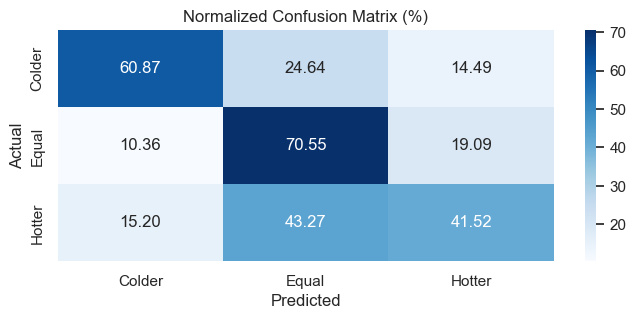

Cross-validation scores: [0.5420712  0.47572816 0.28478964 0.34789644 0.43111831]
Mean cross-validation score: 0.41632075026356785


In [820]:
database =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_merged.csv")
database['ts'] = pd.to_datetime(database['ts'])  # Specify the correct format
database.drop(['weather_main', 'weather_description', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right', 'Temperature_outdoor'], axis=1, inplace=True)
### Turn distance value into bool value (open/closed)
threshold = 50  # Define a threshold for distance
database['distance_left_open'] = database['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database['distance_right_open'] = database['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
database.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database['window_door'] = database['window_door'].replace({0.0: False, 1.0: True})
database['door'] = database['door'].replace({0.0: False, 1.0: True})

df = database

# Create a target variable
df['Temperature_indoor'] = df['Temperature_indoor'].round(1)
df['temp_next'] = df['Temperature_indoor'].shift(1)

# Create a new column to indicate if the next hour is hotter or colder
# Use apply with axis=1 to compare each row's 'temp_next' with the corresponding 'Temperature_indoor'
df['trend'] = df.apply(
    lambda row: 1 if row['temp_next'] > row['Temperature_indoor'] else (-1 if row['temp_next'] < row['Temperature_indoor'] else  0),
    axis=1  # Apply the function row-wise
)

# Data preparation
df['date'] = pd.to_datetime(df['date'])  # Convert the 'date' column to datetime format
# df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)
# df = pd.get_dummies(df, columns=['weather_description'], drop_first=True)

# # Calculate the average temperature of the last week\
# df['Temperature_indoor'] = df['Temperature_indoor'].round(2)
# df['average_temperature_last'] = df['Temperature_indoor'].rolling(window=12*6).mean().shift(12*6)  # Calculate the rolling average of the last 12 hours
# df['average_temperature_last'] = df['Temperature_indoor'].rolling(window=12*6).mean()  # Calculate the rolling average of the last 12 hours
# df['temperature_last'] = df['Temperature_indoor'].shift(12*6)   # get the temperature from 6 hours ago

# Remove rows with NaN values
df.dropna(inplace=True)  # This line removes any rows that contain NaN values

from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns=['Temperature_indoor', 'temp_next', 'trend', 'ts', 'date',  'hr'])
y = df['trend']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

# Initialize the model
model = RandomForestClassifier(random_state=42)

# Fit the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the 
accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
report = classification_report(y_test, y_pred)  # Generate classification report
conf_matrix = confusion_matrix(y_test, y_pred)  # Generate confusion matrix
conf_matrix_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100 # Normalize the confusion matrix to get percentages

# Print evaluation metrics
print("Accuracy:", accuracy)
print("\nClassification Report:\n", report)

# Visualize the normalized confusion matrix
plt.figure(figsize=(8, 3))
sns.heatmap(conf_matrix_percent, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=['Colder', 'Equal', 'Hotter'], yticklabels=['Colder', 'Equal', 'Hotter'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Normalized Confusion Matrix (%)')
plt.show()

# Cross-validate
from sklearn.model_selection import cross_val_score
# Define the number of folds for cross-validation
k = 5  # You can choose any number of folds, commonly 5 or 10
# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=k)  # Evaluate the model using cross-validation
# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)  # Display the scores for each fold
print("Mean cross-validation score:", cv_scores.mean())  # Print the mean score across all folds

In [822]:
X.head()

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,window_door,light_right,light_left,door,distance_left_open,distance_right_open
9,29.4,31.0,28.2,True,1808.0,2769.0,False,False,True
10,29.4,31.0,28.2,True,1762.0,2590.0,False,False,True
11,29.4,30.5,28.2,True,1682.0,2512.0,False,True,True
12,29.3,30.5,28.2,True,1685.0,2485.0,False,True,True
13,29.1,30.0,28.2,True,1685.0,2485.0,False,True,True


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Model: RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)
Accuracy: 0.778125

Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.72      0.75       148
         1.0       0.77      0.83      0.80       172

    accuracy                           0.78       320
   macro avg       0.78      0.77      0.78       320
weighted avg       0.78      0.78      0.78       320



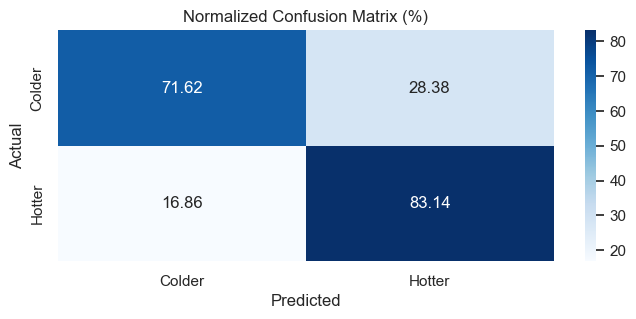

Cross-validation scores: [0.759375  0.690625  0.578125  0.625     0.6677116]
Mean cross-validation score: 0.6641673197492164


In [660]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Define the model
model = RandomForestClassifier(random_state=42)

# Set up the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    # 'max_features': ['auto', 'sqrt'],  # Number of features to consider at every split
    'max_depth': [None, 10, 20, 30],  # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]  # Minimum number of samples required to be at a leaf node
}

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Retrieve the best parameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)
print("Best Model:", best_model)

# Evaluate the best_model
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
report = classification_report(y_test, y_pred)  # Generate classification report
conf_matrix = confusion_matrix(y_test, y_pred)  # Generate confusion matrix
conf_matrix_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100 # Normalize the confusion matrix to get percentages

# Print evaluation metrics
print("Accuracy:", accuracy)
print("\nClassification Report:\n", report)

# Visualize the normalized confusion matrix
plt.figure(figsize=(8, 3))
sns.heatmap(conf_matrix_percent, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=['Colder', 'Hotter'], yticklabels=['Colder', 'Hotter'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Normalized Confusion Matrix (%)')
plt.show()

# Cross-validate
from sklearn.model_selection import cross_val_score
# Define the number of folds for cross-validation
k = 5  # You can choose any number of folds, commonly 5 or 10
# Perform cross-validation
cv_scores = cross_val_score(best_model, X, y, cv=k)  # Evaluate the model using cross-validation
# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)  # Display the scores for each fold
print("Mean cross-validation score:", cv_scores.mean())  # Print the mean score across all folds

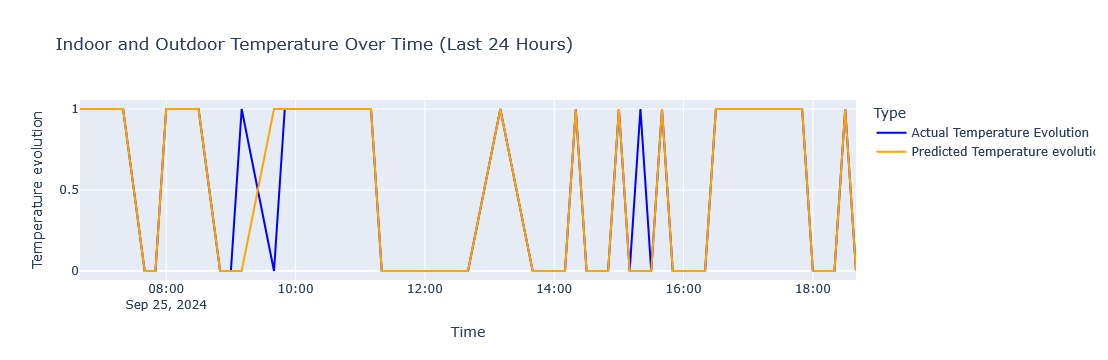

In [662]:
# Convert 'ts' column to datetime format if it's not already
df['ts'] = pd.to_datetime(df['ts'])  # Convert 'ts' to datetime

# Create a new DataFrame to hold the actual and predicted values along with outdoor temperature
results_df = df[['ts', 'trend']].copy()  # Copy the time series and actual indoor temperature
results_df['predicted_trend'] = best_model.predict(X)  # Add predicted indoor temperature using the model

# Filter the results to include only the last 24 hours
last_24_hours = results_df[results_df['ts'] >= results_df['ts'].max() - pd.Timedelta(hours=12)]  # Select data from the last 24 hours

with warnings.catch_warnings(): ## Ignore this future warning since it is a Plotly problem, not a problem with my code
    warnings.simplefilter("ignore", FutureWarning)
    # Create the plotly figure
    fig = go.Figure()
    
    # Add traces for actual indoor temperature, predicted indoor temperature, and outdoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['trend'], mode='lines', name='Actual Temperature Evolution', line=dict(color='blue')))  # Trace for actual indoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['predicted_trend'], mode='lines', name='Predicted Temperature evolution', line=dict(color='orange')))  # Trace for predicted indoor temperature
    
    # Update layout
    fig.update_layout(title='Indoor and Outdoor Temperature Over Time (Last 24 Hours)',  # Set the title of the plot
                      xaxis_title='Time',  # Label for the x-axis
                      yaxis_title='Temperature evolution',  # Label for the y-axis
                      legend_title='Type',  # Title for the legend
                      hovermode='x')  # Enable hover mode for better interaction
    
    # Show the plot
    fig.show()  # Display the plot

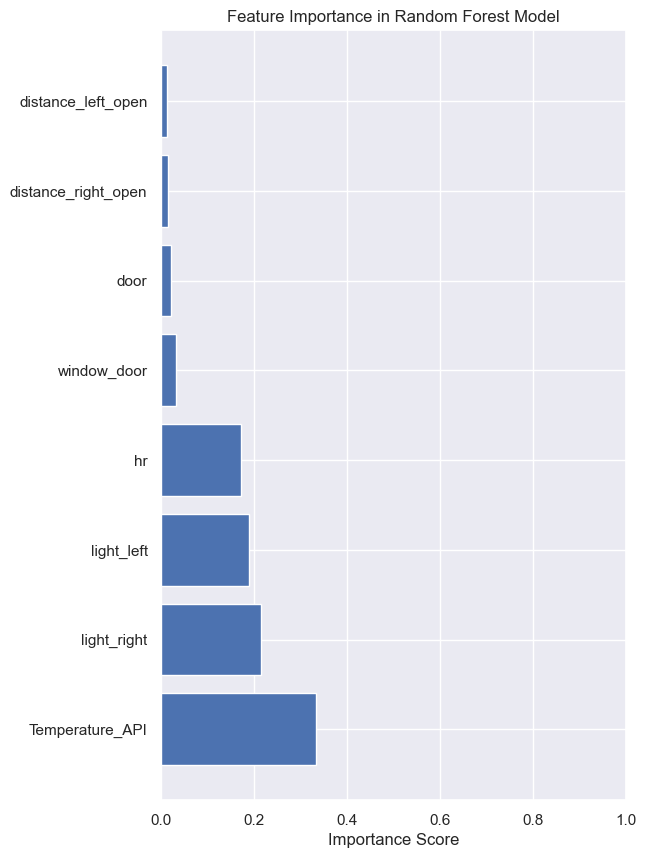

In [752]:
#**Feature Importance**: Analyze the importance of each feature in the model to understand which variables are contributing the most to the predictions.
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances (flipped)
plt.figure(figsize=(6, 10))  # Adjust height for better visualization
plt.title("Feature Importance in Random Forest Model")
plt.barh(X.columns[indices], importances[indices], align="center")  # Use barh for horizontal bars
plt.xlabel("Importance Score")
plt.xlim([0, 1])  # Set x-axis limits to 0 and 1 for normalized importance scores
plt.show()

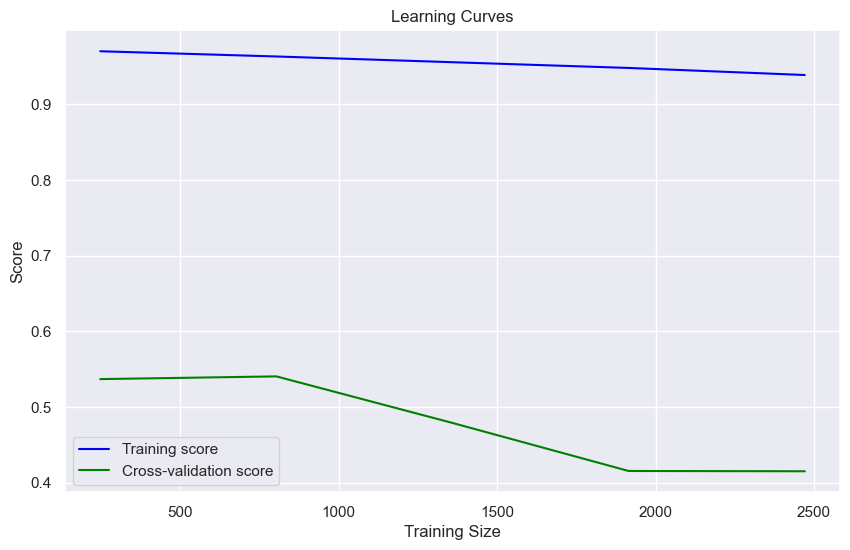

In [824]:
# **Learning Curves**: Plot learning curves to visualize how the model's performance changes with varying training set sizes. 
# This can help identify if the model is underfitting or overfitting.
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(best_model, X, y, cv=5, n_jobs=-1)

# Calculate mean and std for training and test scores
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training score', color='blue')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation score', color='green')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curves')
plt.legend()
plt.show()

## Save this model

In [668]:
import joblib

# Save the trained models to disk
joblib.dump(best_model, 'model_action.pkl')  # Save the left light model

['model_action.pkl']

## Attempt 2/2 (regression)

In [958]:
# Load your data
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_merged.csv")
database_hourly['ts'] = pd.to_datetime(database_hourly['ts'])  # Specify the correct format
database_hourly.drop(['weather_description', 'Temperature_outdoor', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)
### Turn distance value into bool value (open/closed)
threshold = 60  # Define a threshold for distance
database_hourly['distance_left_open'] = database_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_hourly['distance_right_open'] = database_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
database_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database_hourly['window_door'] = database['window_door'].replace({0.0: False, 1.0: True})
database_hourly['door'] = database_hourly['door'].replace({0.0: False, 1.0: True})

df = database_hourly

# Data preparation
# df['date'] = pd.to_datetime(df['date']).astype('int64') / 10**9  # Convert to seconds since epoch
df = pd.get_dummies(df, columns=['weather_main'], drop_first=False)
# df = pd.get_dummies(df, columns=['weather_description'], drop_first=False)

# # Calculate the average temperature of the last week\
df['Temperature_indoor'] = df['Temperature_indoor'].round(2)
# df['temperature_last'] = df['Temperature_indoor'].rolling(window=6*12).mean().shift(12*6)  # Calculate the rolling average of the last 12 hours
# df['temperature_last'] = df['Temperature_indoor'].rolling(window=12*6).mean()  # Calculate the rolling average of the last 12 hours
# df['temperature_last'] = df['temperature_last'].round(2)
# df['temperature_last'] = df['Temperature_indoor'].shift(6*6)   # get the temperature from 6 hours ago

# # Create a target variable indicating whether the indoor temperature is hotter or colder than the average
# df['temp_evolution'] = (df['Temperature_indoor'] > df['average_temperature_last']).astype(int)  # 1 if hotter, 0 if colder
# df['temp_evolution'] = (df['Temperature_indoor'] > df['Temperature_indoor'].shift(1)).astype(int)  # 1 if hotter, 0 if colder

# Remove rows with NaN values
df.dropna(inplace=True)  # This line removes any rows that contain NaN values

# Define features and target
X = df.drop(columns=['Temperature_indoor', 'date', 'ts'])
# X = df.drop(columns=['Temperature_indoor', 'date', 'ts'])
y = df['Temperature_indoor']

# Remove rows with NaN values
df.dropna(inplace=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Train the model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # Calculate R-squared value

# Print the evaluation metrics
print(f'MAE: {mae}, MSE: {mse}, R-squared: {r2}')  # Print the evaluation metrics including R-squared

# **Cross-Validation**: Instead of a single train-test split, use k-fold cross-validation to assess the model's performance more robustly. 
# This helps in understanding how the model generalizes to an independent dataset.
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')   # Use negative MAE for scoring
# Calculate the mean of the cross-validated scores and negate it to get the actual MAE
print(f'Cross-validated MAE: {-cv_scores.mean()}')  # Print the mean absolute error from cross-validation

MAE: 0.29555241628831475, MSE: 0.252424936018206, R-squared: 0.9136093967084178
Cross-validated MAE: 1.0421901697815827


In [966]:
X.head()

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,window_door,light_right,light_left,door,hr,distance_left_open,distance_right_open,weather_main_Clear,weather_main_Clouds,weather_main_Rain
9,29.4,31.0,28.2,True,1808.0,2769.0,False,18,False,False,False,True,False
10,29.4,31.0,28.2,True,1762.0,2590.0,False,18,False,True,False,True,False
11,29.4,30.5,28.2,True,1682.0,2512.0,False,18,True,True,False,True,False
12,29.3,30.5,28.2,True,1685.0,2485.0,False,18,True,True,False,True,False
13,29.1,30.0,28.2,True,1685.0,2485.0,False,18,True,True,False,True,False


In [962]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
   'n_estimators': [100, 200, 300],
   'max_depth': [None, 10, 20, 30],
   'min_samples_split': [2, 5, 10],
   'min_samples_leaf': [1, 2, 4],
   # 'max_features': [1.0, 'sqrt', 'log2']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=2) # Set up the parameter grid
grid_search.fit(X_train, y_train) # Fit the grid search to the data

# Retrieve the best parameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Now you can use best_model to make predictions on your test data
y_pred = best_model.predict(X_test)

# Optionally, you can evaluate the model's performance
from sklearn.metrics import mean_absolute_error

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # Calculate R-squared value

print(f'MAE: {mae}, MSE: {mse}, R-squared: {r2}')  # Print the evaluation metrics including R-squared

# **Cross-Validation**: Instead of a single train-test split, use k-fold cross-validation to assess the model's performance more robustly. 
# This helps in understanding how the model generalizes to an independent dataset.
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_absolute_error')   # Use negative MAE for scoring
# Calculate the mean of the cross-validated scores and negate it to get the actual MAE
print(f'Cross-validated MAE: {-cv_scores.mean()}')  # Print the mean absolute error from cross-validation

Fitting 5 folds for each of 108 candidates, totalling 540 fits
MAE: 0.28963700289964445, MSE: 0.24590650853279789, R-squared: 0.9158402812313963
Cross-validated MAE: 1.0453527533248037


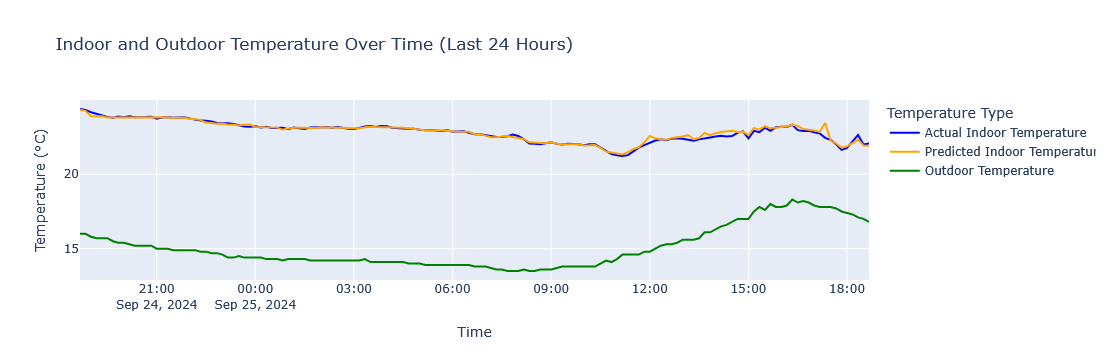

In [968]:
# Convert 'ts' column to datetime format if it's not already
df['ts'] = pd.to_datetime(df['ts'])  # Convert 'ts' to datetime

# Create a new DataFrame to hold the actual and predicted values along with outdoor temperature
results_df = df[['ts', 'Temperature_indoor']].copy()  # Copy the time series and actual indoor temperature
results_df['predicted_Temperature_indoor'] = best_model.predict(X)  # Add predicted indoor temperature using the model
results_df['Temperature_API'] = df['Temperature_API']  # Include outdoor temperature from the original dataframe

# Filter the results to include only the last 24 hours
last_24_hours = results_df[results_df['ts'] >= results_df['ts'].max() - pd.Timedelta(hours=24)]  # Select data from the last 24 hours

with warnings.catch_warnings(): ## Ignore this future warning since it is a Plotly problem, not a problem with my code
    warnings.simplefilter("ignore", FutureWarning)
    # Create the plotly figure
    fig = go.Figure()
    
    # Add traces for actual indoor temperature, predicted indoor temperature, and outdoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['Temperature_indoor'], mode='lines', name='Actual Indoor Temperature', line=dict(color='blue')))  # Trace for actual indoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['predicted_Temperature_indoor'], mode='lines', name='Predicted Indoor Temperature', line=dict(color='orange')))  # Trace for predicted indoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['Temperature_API'], mode='lines', name='Outdoor Temperature', line=dict(color='green')))  # Trace for outdoor temperature
    
    # Update layout
    fig.update_layout(title='Indoor and Outdoor Temperature Over Time (Last 24 Hours)',  # Set the title of the plot
                      xaxis_title='Time',  # Label for the x-axis
                      yaxis_title='Temperature (°C)',  # Label for the y-axis
                      legend_title='Temperature Type',  # Title for the legend
                      hovermode='x')  # Enable hover mode for better interaction
    
    # Show the plot
    fig.show()  # Display the plot

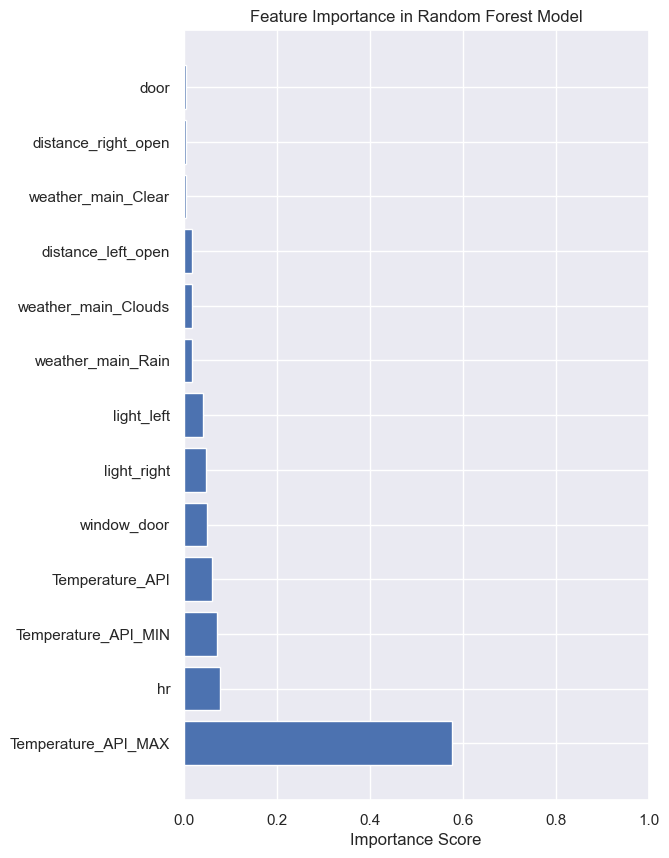

In [970]:
#**Feature Importance**: Analyze the importance of each feature in the model to understand which variables are contributing the most to the predictions.
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the model
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances (flipped)
plt.figure(figsize=(6, 10))  # Adjust height for better visualization
plt.title("Feature Importance in Random Forest Model")
plt.barh(X.columns[indices], importances[indices], align="center")  # Use barh for horizontal bars
plt.xlabel("Importance Score")
plt.xlim([0, 1])  # Set x-axis limits to 0 and 1 for normalized importance scores
plt.show()

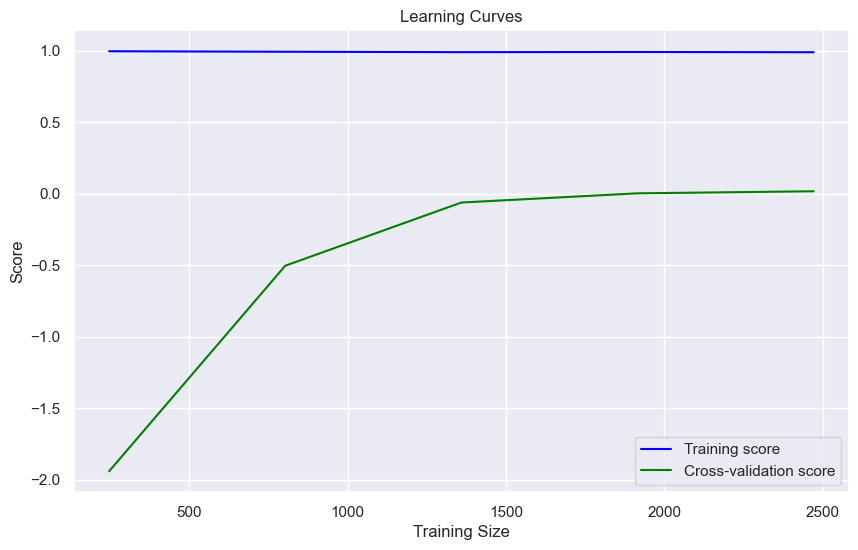

In [972]:
# **Learning Curves**: Plot learning curves to visualize how the model's performance changes with varying training set sizes. 
# This can help identify if the model is underfitting or overfitting.
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(best_model, X, y, cv=5, n_jobs=-1)

# Calculate mean and std for training and test scores
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training score', color='blue')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation score', color='green')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curves')
plt.legend()
plt.show()

## Save this model

In [974]:
import joblib

# Save the trained models to disk
joblib.dump(best_model, 'model_action.pkl')  # Save the left light model

['model_action.pkl']

# Model to Predict the indoor temperature

## Attempt 1/2 (count open/closed durations)

In [891]:
## BASELINE MODEL (mean prediction)
# Load your data
# Load your data
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_hourly.csv")
database_hourly['ts'] = pd.to_datetime(database_hourly['ts'])  # Specify the correct format
database_hourly.drop(['weather_description', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)
### Turn distance value into bool value (open/closed)
threshold = 50  # Define a threshold for distance
database_hourly['distance_left_open'] = database_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_hourly['distance_right_open'] = database_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
database_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database_hourly['window_door'] = database['window_door'].replace({0.0: False, 1.0: True})
database_hourly['door'] = database_hourly['door'].replace({0.0: False, 1.0: True})

df = database_hourly


# Data preparation
df['date'] = pd.to_datetime(df['date'])
df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

# Create cumulative features for "window_door"
df['window_door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['window_door'] = df['window_door'].astype(int)
df['window_open_duration'] = df['window_door'].groupby((df['window_door'] != df['window_door'].shift()).cumsum()).cumsum()  # Count consecutive open periods
df['window_closed_duration'] = (df['window_door'] == 0).astype(int)  # Create a binary column where 1 indicates the window is closed
df['window_closed_duration'] = df['window_closed_duration'].groupby((df['window_closed_duration'] != df['window_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# Create consecutive counts for 'door'
df['door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['door'] = df['door'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['door_open_duration'] = df['door'].groupby((df['door'] != df['door'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['door_closed_duration'] = (df['door'] == 0).astype(int)  # Create a binary column for closed door
df['door_closed_duration'] = df['door_closed_duration'].groupby((df['door_closed_duration'] != df['door_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods for door

# Create consecutive counts for 'distance_left_open'
df['distance_left_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['distance_left_open'] = df['distance_left_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['distance_left_open_duration'] = df['distance_left_open'].groupby((df['distance_left_open'] != df['distance_left_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['distance_left_closed_duration'] = (df['distance_left_open'] == 0).astype(int)  # Create a binary column for closed door
df['distance_left_closed_duration'] = df['distance_left_closed_duration'].groupby((df['distance_left_closed_duration'] != df['distance_left_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# Create consecutive counts for 'distance_right_open'
df['distance_right_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['distance_right_open'] = df['distance_right_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['distance_right_open_duration'] = df['distance_right_open'].groupby((df['distance_right_open'] != df['distance_right_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['distance_right_closed_duration'] = (df['distance_right_open'] == 0).astype(int)  # Create a binary column for closed door
df['distance_right_closed_duration'] = df['distance_right_closed_duration'].groupby((df['distance_right_closed_duration'] != df['distance_right_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# # Calculate the average temperature of the last week\
# df['Temperature_indoor'] = df['Temperature_indoor'].round(2)
# # df['average_temperature_last'] = df['Temperature_indoor'].rolling(window=12).mean().shift(12)  # Calculate the rolling average of the last 12 hours
df['temperature_last'] = df['Temperature_indoor'].shift(12)  # get the temperature from 6 hours ago
# df['average_temperature_last'] = df['Temperature_indoor'].rolling(window=12).mean()  # Calculate the rolling average of the last 12 hours


# Remove rows with NaN values
df.dropna(inplace=True)  # This line removes any rows that contain NaN values

# Define features and target
X = df.drop(columns=['Temperature_indoor', 'date', 'ts', 'window_door', "door", 'distance_left_open', 'distance_right_open'])
y = df['Temperature_indoor']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


# Assuming y_train is your training target variable and y_test is your test target variable

# Step 1: Calculate the mean of the training target variable
mean_prediction = np.mean(y_train)

# Step 2: Create predictions for the test set using the mean
y_pred_baseline = np.full_like(y_test, mean_prediction)

# Step 3: Evaluate the baseline model using MAE
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)

print(f'Baseline MAE (Mean Prediction): {baseline_mae}')

Baseline MAE (Mean Prediction): 1.5322934877622376


In [1222]:
# Load your data
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_merged.csv")
database_hourly['ts'] = pd.to_datetime(database_hourly['ts'])  # Specify the correct format
database_hourly.drop(['weather_main', 'weather_description', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)
### Turn distance value into bool value (open/closed)
threshold = 50  # Define a threshold for distance
database_hourly['distance_left_open'] = database_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_hourly['distance_right_open'] = database_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
database_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database_hourly['window_door'] = database['window_door'].replace({0.0: False, 1.0: True})
database_hourly['door'] = database_hourly['door'].replace({0.0: False, 1.0: True})

df = database_hourly

# Data preparation
# df['date'] = pd.to_datetime(df['date']).astype('int64') / 10**9  # Convert to seconds since epoch
# df = pd.get_dummies(df, columns=['weather_main'], drop_first=False)
# df = pd.get_dummies(df, columns=['weather_description'], drop_first=False)

# Create cumulative features for "window_door"
df['window_door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['window_door'] = df['window_door'].astype(int)
df['window_open_duration'] = df['window_door'].groupby((df['window_door'] != df['window_door'].shift()).cumsum()).cumsum()  # Count consecutive open periods
df['window_closed_duration'] = (df['window_door'] == 0).astype(int)  # Create a binary column where 1 indicates the window is closed
df['window_closed_duration'] = df['window_closed_duration'].groupby((df['window_closed_duration'] != df['window_closed_duration'].shift(6)).cumsum()).cumsum()  # Count consecutive closed periods

# Create consecutive counts for 'door'
df['door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['door'] = df['door'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['door_open_duration'] = df['door'].groupby((df['door'] != df['door'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['door_closed_duration'] = (df['door'] == 0).astype(int)  # Create a binary column for closed door
df['door_closed_duration'] = df['door_closed_duration'].groupby((df['door_closed_duration'] != df['door_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods for door

# Create consecutive counts for 'distance_left_open'
df['distance_left_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['distance_left_open'] = df['distance_left_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['distance_left_open_duration'] = df['distance_left_open'].groupby((df['distance_left_open'] != df['distance_left_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['distance_left_closed_duration'] = (df['distance_left_open'] == 0).astype(int)  # Create a binary column for closed door
df['distance_left_closed_duration'] = df['distance_left_closed_duration'].groupby((df['distance_left_closed_duration'] != df['distance_left_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# Create consecutive counts for 'distance_right_open'
df['distance_right_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['distance_right_open'] = df['distance_right_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['distance_right_open_duration'] = df['distance_right_open'].groupby((df['distance_right_open'] != df['distance_right_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['distance_right_closed_duration'] = (df['distance_right_open'] == 0).astype(int)  # Create a binary column for closed door
df['distance_right_closed_duration'] = df['distance_right_closed_duration'].groupby((df['distance_right_closed_duration'] != df['distance_right_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# # Calculate the average temperature of the last week\
# df['Temperature_indoor'] = df['Temperature_indoor'].round(2)
# df['temperature_last'] = df['Temperature_indoor'].rolling(window=12).mean().shift(12)  # Calculate the rolling average of the last 12 hours
# df['average_temperature_last'] = df['Temperature_indoor'].rolling(window=12).mean()  # Calculate the rolling average of the last 12 hours
# df['temperature_last'] = df['Temperature_indoor'].shift(12)  # get the temperature from 6 hours ago

# # Create a target variable indicating whether the indoor temperature is hotter or colder than the average
# df['temp_evolution'] = (df['Temperature_indoor'] > df['average_temperature_last']).astype(int)  # 1 if hotter, 0 if colder
# df['temp_evolution'] = (df['Temperature_indoor'] > df['Temperature_indoor'].shift(1)).astype(int)  # 1 if hotter, 0 if colder



# Data preparation
# df['date'] = pd.to_datetime(df['date']).astype('int64') / 10**9  # Convert to seconds since epoch
# df = pd.get_dummies(df, columns=['weather_main'], drop_first=False)
# df = pd.get_dummies(df, columns=['weather_description'], drop_first=False)
# df['Temperature_API'] = df['Temperature_API'].round(2)
# df['Temperature_API_MAX'] = df['Temperature_API_MAX'].round(2)
# df['Temperature_API_MIN'] = df['Temperature_API_MIN'].round(2)
# df['trend_API'] = (df['Temperature_API'].diff()).round(3)
# df['trend_API_MAX'] = (df['Temperature_API_MAX'].diff()).round(3)
# df['trend_API_MIN'] = (df['Temperature_API_MIN'].diff()).round(3)


# # Calculate the average temperature of the last week\
df['Temperature_indoor'] = df['Temperature_indoor'].round(2)
# df['temperature_trend'] = (df['Temperature_indoor'].diff()).round(3)
# df['temperature_trend'] = df.Temperature_indoor.pct_change(fill_method=None).round(2) # for the hourly databse (comparable to api forecast)

# df['Percentual Difference_indoor'] = ((df['Temperature_indoor'] - df['Temperature_indoor'].shift(1)) / df['Temperature_indoor'].shift(1)).fillna(0) * 100



# Remove rows with NaN values
df.dropna(inplace=True)  # This line removes any rows that contain NaN values

# Define features and target
# X = df.drop(columns=[ 'temperature_trend', 'Temperature_indoor', 'date', 'ts', 'window_door', "door", 'distance_left_open', 'distance_right_open'])
# X = df.drop(columns=['temperature_trend', 'Temperature_indoor', 'date', 'ts'])
X = df[['light_left', 'light_right', 'Temperature_API', 'Temperature_API_MAX', 'Temperature_API_MIN', 'window_open_duration', 'door_open_duration', 'distance_left_open_duration', 'distance_right_open_duration', 'hr']]

y = df['Temperature_indoor']

# Remove rows with NaN values
df.dropna(inplace=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Train the model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # Calculate R-squared value

# Print the evaluation metrics
print(f'MAE: {mae}, MSE: {mse}, R-squared: {r2}')  # Print the evaluation metrics including R-squared

# **Cross-Validation**: Instead of a single train-test split, use k-fold cross-validation to assess the model's performance more robustly. 
# This helps in understanding how the model generalizes to an independent dataset.
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')   # Use negative MAE for scoring
# Calculate the mean of the cross-validated scores and negate it to get the actual MAE
print(f'Cross-validated MAE: {-cv_scores.mean()}')  # Print the mean absolute error from cross-validation

MAE: 0.2899793243039994, MSE: 0.21531905334685716, R-squared: 0.9227482356247494
Cross-validated MAE: 1.1204060674620346


In [1198]:
X.head()

,light_left,light_right,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,window_door,door,distance_left_open,distance_right_open,window_open_duration,door_open_duration,distance_left_open_duration,distance_right_open_duration
9,2769.0,1808.0,29.4,31.0,28.2,1,0,0,1,1,0,0,10
10,2590.0,1762.0,29.4,31.0,28.2,1,0,0,1,2,0,0,11
11,2512.0,1682.0,29.4,30.5,28.2,1,0,1,1,3,0,1,12
12,2485.0,1685.0,29.3,30.5,28.2,1,0,1,1,4,0,2,13
13,2485.0,1685.0,29.1,30.0,28.2,1,0,1,1,5,0,3,14


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
   'n_estimators': [100, 200, 300],
   'max_depth': [None, 10, 20, 30],
   'min_samples_split': [2, 5, 10],
   'min_samples_leaf': [1, 2, 4],
   # 'max_features': [1.0, 'sqrt', 'log2']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=2) # Set up the parameter grid
grid_search.fit(X_train, y_train) # Fit the grid search to the data

# Retrieve the best parameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Now you can use best_model to make predictions on your test data
y_pred = best_model.predict(X_test)

# Optionally, you can evaluate the model's performance
from sklearn.metrics import mean_absolute_error

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # Calculate R-squared value

print(f'MAE: {mae}, MSE: {mse}, R-squared: {r2}')  # Print the evaluation metrics including R-squared

# **Cross-Validation**: Instead of a single train-test split, use k-fold cross-validation to assess the model's performance more robustly. 
# This helps in understanding how the model generalizes to an independent dataset.
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_absolute_error')   # Use negative MAE for scoring
# Calculate the mean of the cross-validated scores and negate it to get the actual MAE
print(f'Cross-validated MAE: {-cv_scores.mean()}')  # Print the mean absolute error from cross-validation

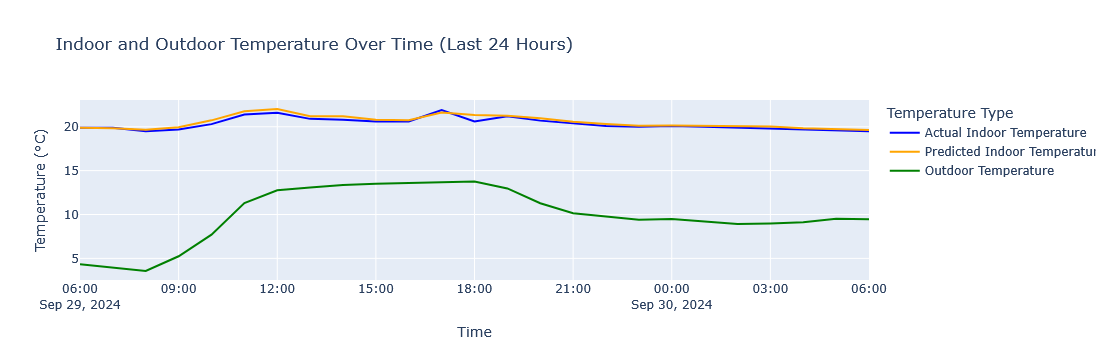

In [1008]:
# Convert 'ts' column to datetime format if it's not already
df['ts'] = pd.to_datetime(df['ts'])  # Convert 'ts' to datetime

# Create a new DataFrame to hold the actual and predicted values along with outdoor temperature
results_df = df[['ts', 'Temperature_indoor']].copy()  # Copy the time series and actual indoor temperature
results_df['predicted_Temperature_indoor'] = best_model.predict(X)  # Add predicted indoor temperature using the model
results_df['Temperature_API'] = df['Temperature_API']  # Include outdoor temperature from the original dataframe

# Filter the results to include only the last 24 hours
last_24_hours = results_df[results_df['ts'] >= results_df['ts'].max() - pd.Timedelta(hours=24)]  # Select data from the last 24 hours

with warnings.catch_warnings(): ## Ignore this future warning since it is a Plotly problem, not a problem with my code
    warnings.simplefilter("ignore", FutureWarning)
    # Create the plotly figure
    fig = go.Figure()
    
    # Add traces for actual indoor temperature, predicted indoor temperature, and outdoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['Temperature_indoor'], mode='lines', name='Actual Indoor Temperature', line=dict(color='blue')))  # Trace for actual indoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['predicted_Temperature_indoor'], mode='lines', name='Predicted Indoor Temperature', line=dict(color='orange')))  # Trace for predicted indoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['Temperature_API'], mode='lines', name='Outdoor Temperature', line=dict(color='green')))  # Trace for outdoor temperature
    
    # Update layout
    fig.update_layout(title='Indoor and Outdoor Temperature Over Time (Last 24 Hours)',  # Set the title of the plot
                      xaxis_title='Time',  # Label for the x-axis
                      yaxis_title='Temperature (°C)',  # Label for the y-axis
                      legend_title='Temperature Type',  # Title for the legend
                      hovermode='x')  # Enable hover mode for better interaction
    
    # Show the plot
    fig.show()  # Display the plot

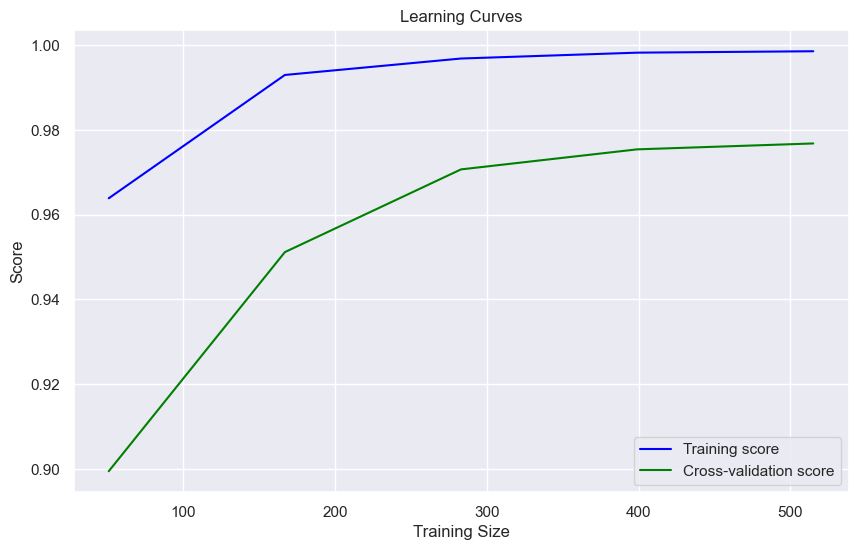

In [1117]:
# **Learning Curves**: Plot learning curves to visualize how the model's performance changes with varying training set sizes. 
# This can help identify if the model is underfitting or overfitting.
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, n_jobs=-1)

# Calculate mean and std for training and test scores
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training score', color='blue')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation score', color='green')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curves')
plt.legend()
plt.show()

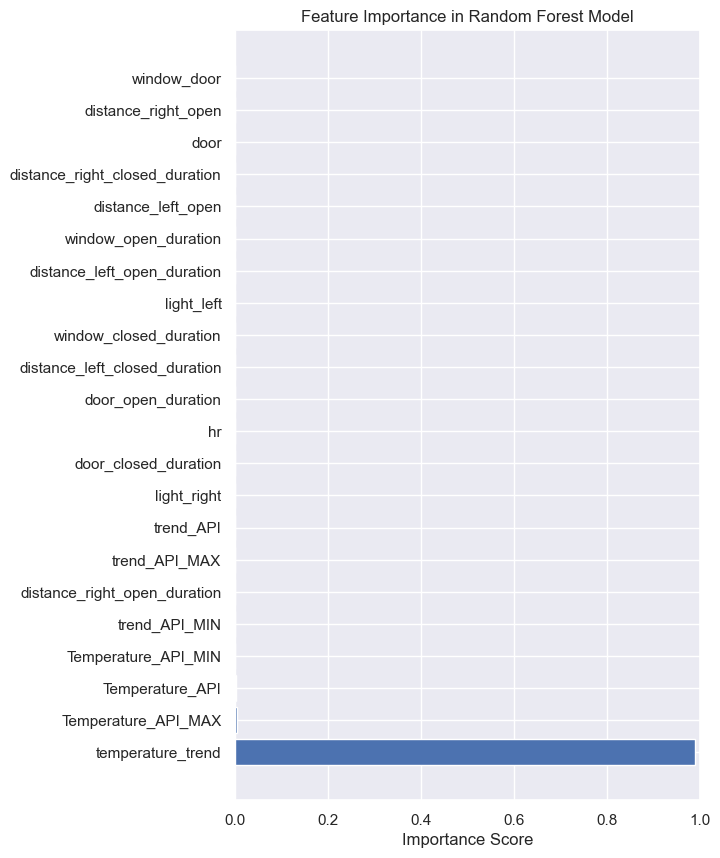

In [1119]:
#**Feature Importance**: Analyze the importance of each feature in the model to understand which variables are contributing the most to the predictions.
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances (flipped)
plt.figure(figsize=(6, 10))  # Adjust height for better visualization
plt.title("Feature Importance in Random Forest Model")
plt.barh(X.columns[indices], importances[indices], align="center")  # Use barh for horizontal bars
plt.xlabel("Importance Score")
plt.xlim([0, 1])  # Set x-axis limits to 0 and 1 for normalized importance scores
plt.show()

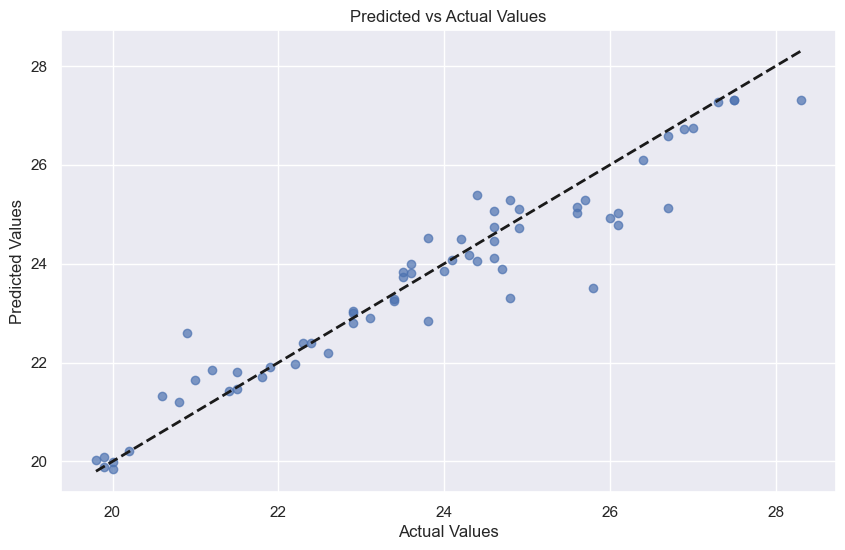

In [1014]:
### 2. Predicted vs Actual Values

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values")
plt.show()

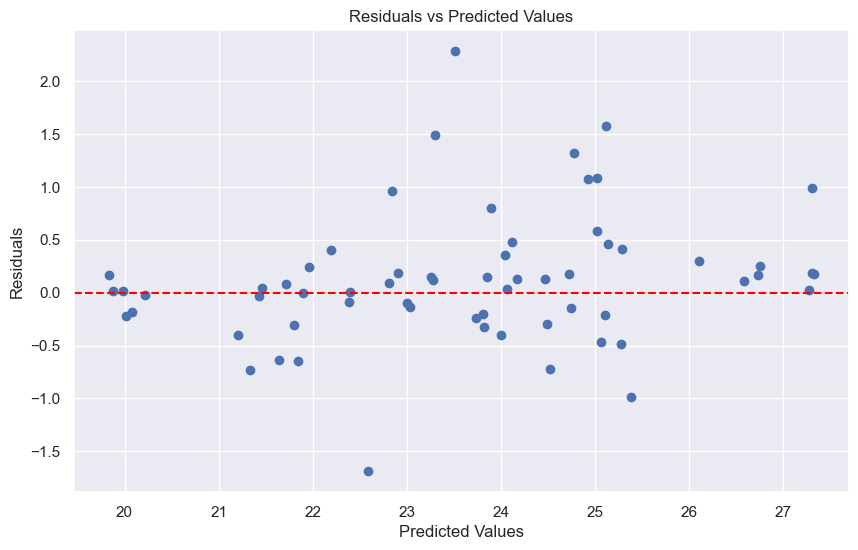

In [1016]:
# **Residual Analysis**: Examine the residuals (the differences between predicted and actual values) to check for patterns. Ideally, residuals should be randomly distributed.
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()   

### Save this model

In [1018]:
import joblib

# Save the trained models to disk
joblib.dump(model, 'model_temp.pkl')  # Save the left light model

['model_temp.pkl']

## Attempt 1/2 (incrementally - regression)

In [1099]:
# Load your data
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_merged.csv")
database_hourly['ts'] = pd.to_datetime(database_hourly['ts'])  # Specify the correct format
database_hourly.drop(['weather_description', 'weather_main', 'Temperature_outdoor', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)
### Turn distance value into bool value (open/closed)
threshold = 60  # Define a threshold for distance
database_hourly['distance_left_open'] = database_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_hourly['distance_right_open'] = database_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
database_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database_hourly['window_door'] = database['window_door'].replace({0.0: False, 1.0: True})
database_hourly['door'] = database_hourly['door'].replace({0.0: False, 1.0: True})

df = database_hourly

# Data preparation
# df['date'] = pd.to_datetime(df['date']).astype('int64') / 10**9  # Convert to seconds since epoch
# df = pd.get_dummies(df, columns=['weather_main'], drop_first=False)
# df = pd.get_dummies(df, columns=['weather_description'], drop_first=False)
df['Temperature_API'] = df['Temperature_API'].round(2)
df['Temperature_API_MAX'] = df['Temperature_API_MAX'].round(2)
df['Temperature_API_MIN'] = df['Temperature_API_MIN'].round(2)
# df['Percentual Difference_API'] = ((df['Temperature_API'] - df['Temperature_API'].shift(1)) / df['Temperature_API'].shift(1)).fillna(0) * 100
# df['Percentual Difference_APIMAX'] = ((df['Temperature_API_MAX'] - df['Temperature_API_MAX'].shift(1)) / df['Temperature_API_MAX'].shift(1)).fillna(0) * 100
# df['Percentual Difference__APIMIN'] = ((df['Temperature_API_MIN'] - df['Temperature_API_MIN'].shift(1)) / df['Temperature_API_MIN'].shift(1)).fillna(0) * 100

df['trend_API'] = (df['Temperature_API'].diff()).round(3)
df['trend_API_MAX'] = (df['Temperature_API_MAX'].diff()).round(3)
df['trend_API_MIN'] = (df['Temperature_API_MIN'].diff()).round(3)

# # Calculate the average temperature of the last week\
df['Temperature_indoor'] = df['Temperature_indoor'].round(2)
# df['temperature_last'] = df['Temperature_indoor'].rolling(window=6*12).mean().shift(12*6)  # Calculate the rolling average of the last 12 hours
# df['temperature_last'] = df['Temperature_indoor'].rolling(window=12*6).mean()  # Calculate the rolling average of the last 12 hours
# df['temperature_last'] = df['temperature_last'].round(2)
# df['temperature_last'] = df['Temperature_indoor'].shift(6*6)   # get the temperature from 6 hours ago
df['temperature_trend'] = (df['Temperature_indoor'].diff()).round(3)
# df['Percentual Difference_indoor'] = ((df['Temperature_indoor'] - df['Temperature_indoor'].shift(1)) / df['Temperature_indoor'].shift(1)).fillna(0) * 100

# df['temperature_trend'] = df['temperature_trend'].round(2)

# # Create a target variable indicating whether the indoor temperature is hotter or colder than the average
# df['temp_evolution'] = (df['Temperature_indoor'] > df['average_temperature_last']).astype(int)  # 1 if hotter, 0 if colder
# df['temp_evolution'] = (df['Temperature_indoor'] > df['Temperature_indoor'].shift(1)).astype(int)  # 1 if hotter, 0 if colder

# Remove rows with NaN values
df.dropna(inplace=True)  # This line removes any rows that contain NaN values

# Define features and target
X = df.drop(columns=['Temperature_indoor', 'temperature_trend', 'date', 'ts'])
# X = df.drop(columns=['Temperature_indoor', 'date', 'ts'])
y = df['temperature_trend']

# Remove rows with NaN values
df.dropna(inplace=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Train the model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # Calculate R-squared value

# Print the evaluation metrics
print(f'MAE: {mae}, MSE: {mse}, R-squared: {r2}')  # Print the evaluation metrics including R-squared

# **Cross-Validation**: Instead of a single train-test split, use k-fold cross-validation to assess the model's performance more robustly. 
# This helps in understanding how the model generalizes to an independent dataset.

from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')   # Use negative MAE for scoring
# Calculate the mean of the cross-validated scores and negate it to get the actual MAE
print(f'Cross-validated MAE: {-cv_scores.mean()}')  # Print the mean absolute error from cross-validation

MAE: 0.08632584415584416, MSE: 0.03549307185800866, R-squared: 0.27507737524945175
Cross-validated MAE: 0.1032284219256199


This is a really bad model even though the MAE is low (the temp difference values are also very small)

In [1081]:
X.head()

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,window_door,light_right,light_left,door,hr,distance_left_open,distance_right_open,trend_API,trend_API_MAX,trend_API_MIN
10,29.4,31.0,28.2,True,1762.0,2590.0,False,18,False,True,0.0,0.0,0.0
11,29.4,30.5,28.2,True,1682.0,2512.0,False,18,True,True,0.0,-0.5,0.0
12,29.3,30.5,28.2,True,1685.0,2485.0,False,18,True,True,-0.1,0.0,0.0
13,29.1,30.0,28.2,True,1685.0,2485.0,False,18,True,True,-0.2,-0.5,0.0
14,28.9,30.0,27.6,True,1685.0,2485.0,False,19,True,True,-0.2,0.0,-0.6


In [1093]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
   'n_estimators': [100, 200, 300],
   'max_depth': [None, 10, 20, 30],
   'min_samples_split': [2, 5, 10],
   'min_samples_leaf': [1, 2, 4],
   # 'max_features': [1.0, 'sqrt', 'log2']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=2) # Set up the parameter grid
grid_search.fit(X_train, y_train) # Fit the grid search to the data

# Retrieve the best parameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Now you can use best_model to make predictions on your test data
y_pred = best_model.predict(X_test)

# Optionally, you can evaluate the model's performance
from sklearn.metrics import mean_absolute_error

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # Calculate R-squared value

print(f'MAE: {mae}, MSE: {mse}, R-squared: {r2}')  # Print the evaluation metrics including R-squared

# **Cross-Validation**: Instead of a single train-test split, use k-fold cross-validation to assess the model's performance more robustly. 
# This helps in understanding how the model generalizes to an independent dataset.
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_absolute_error')   # Use negative MAE for scoring
# Calculate the mean of the cross-validated scores and negate it to get the actual MAE
print(f'Cross-validated MAE: {-cv_scores.mean()}')  # Print the mean absolute error from cross-validation

Fitting 5 folds for each of 108 candidates, totalling 540 fits
MAE: 0.07078174740081014, MSE: 0.026624887932651612, R-squared: 0.3653491436740176
Cross-validated MAE: 0.09920718778896306


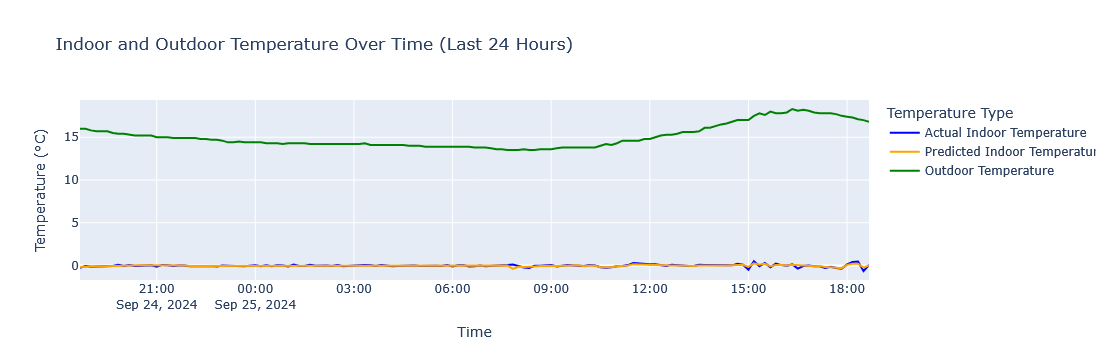

In [981]:
# Convert 'ts' column to datetime format if it's not already
df['ts'] = pd.to_datetime(df['ts'])  # Convert 'ts' to datetime

# Create a new DataFrame to hold the actual and predicted values along with outdoor temperature
results_df = df[['ts', 'temperature_trend']].copy()  # Copy the time series and actual indoor temperature
results_df['predicted_temperature_trend'] = best_model.predict(X)  # Add predicted indoor temperature using the model
results_df['Temperature_API'] = df['Temperature_API']  # Include outdoor temperature from the original dataframe

# Filter the results to include only the last 24 hours
last_24_hours = results_df[results_df['ts'] >= results_df['ts'].max() - pd.Timedelta(hours=24)]  # Select data from the last 24 hours

with warnings.catch_warnings(): ## Ignore this future warning since it is a Plotly problem, not a problem with my code
    warnings.simplefilter("ignore", FutureWarning)
    # Create the plotly figure
    fig = go.Figure()
    
    # Add traces for actual indoor temperature, predicted indoor temperature, and outdoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['temperature_trend'], mode='lines', name='Actual Indoor Temperature', line=dict(color='blue')))  # Trace for actual indoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['predicted_temperature_trend'], mode='lines', name='Predicted Indoor Temperature', line=dict(color='orange')))  # Trace for predicted indoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['Temperature_API'], mode='lines', name='Outdoor Temperature', line=dict(color='green')))  # Trace for outdoor temperature
    
    # Update layout
    fig.update_layout(title='Indoor and Outdoor Temperature Over Time (Last 24 Hours)',  # Set the title of the plot
                      xaxis_title='Time',  # Label for the x-axis
                      yaxis_title='Temperature (°C)',  # Label for the y-axis
                      legend_title='Temperature Type',  # Title for the legend
                      hovermode='x')  # Enable hover mode for better interaction
    
    # Show the plot
    fig.show()  # Display the plot

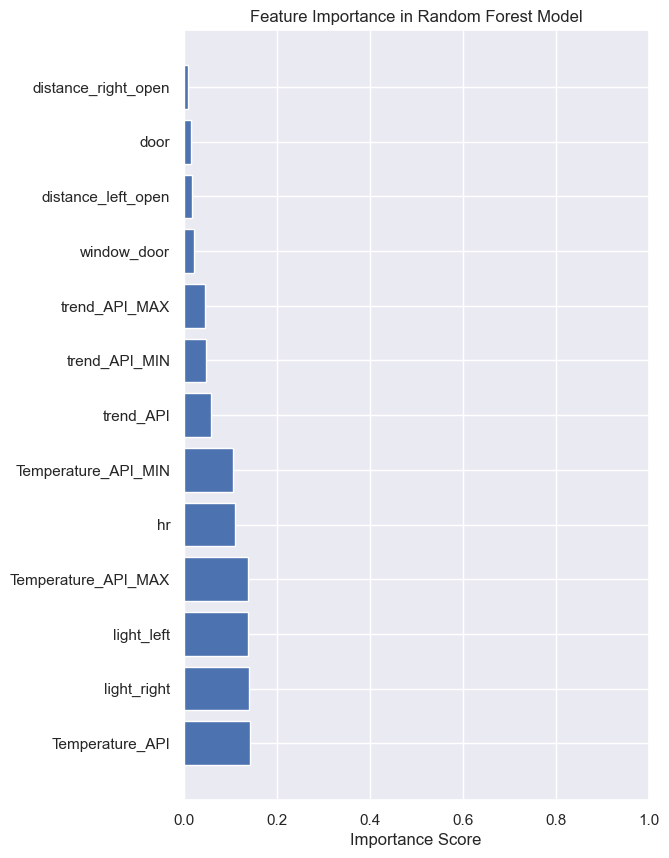

In [1091]:
#**Feature Importance**: Analyze the importance of each feature in the model to understand which variables are contributing the most to the predictions.
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances (flipped)
plt.figure(figsize=(6, 10))  # Adjust height for better visualization
plt.title("Feature Importance in Random Forest Model")
plt.barh(X.columns[indices], importances[indices], align="center")  # Use barh for horizontal bars
plt.xlabel("Importance Score")
plt.xlim([0, 1])  # Set x-axis limits to 0 and 1 for normalized importance scores
plt.show()

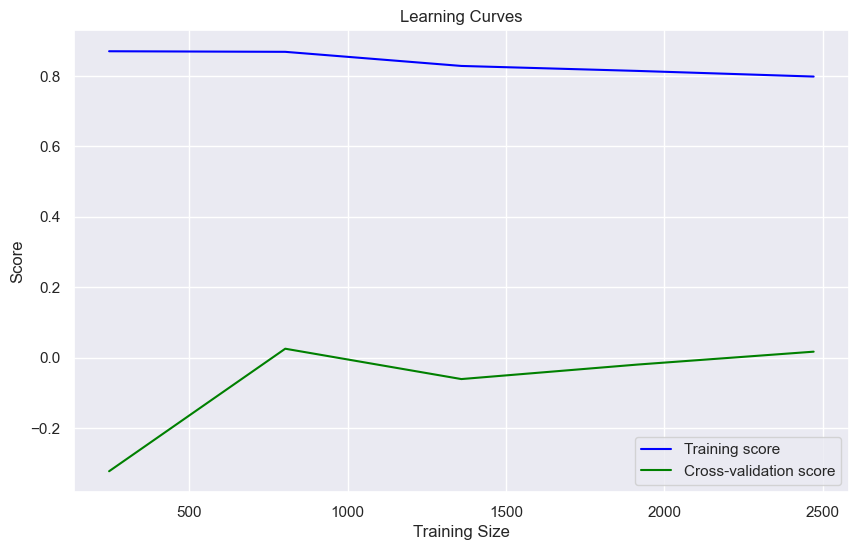

In [942]:
# **Learning Curves**: Plot learning curves to visualize how the model's performance changes with varying training set sizes. 
# This can help identify if the model is underfitting or overfitting.
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(best_model, X, y, cv=5, n_jobs=-1)

# Calculate mean and std for training and test scores
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training score', color='blue')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation score', color='green')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curves')
plt.legend()
plt.show()

## Save this model

In [944]:
import joblib

# Save the trained models to disk
joblib.dump(best_model, 'model_temp.pkl')  # Save the left light model

['model_action.pkl']